In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_ROOT = "split_dataset"

train_ds = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\train",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"], 
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\val",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\test",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 2419 files belonging to 2 classes.
Found 318 files belonging to 2 classes.
Found 661 files belonging to 2 classes.


In [3]:
from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Phase 1

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
model.summary()

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.5345 - auc: 0.5403 - loss: 0.8356 - val_accuracy: 0.5377 - val_auc: 0.5730 - val_loss: 0.7291
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.5883 - auc: 0.6202 - loss: 0.7083 - val_accuracy: 0.5912 - val_auc: 0.6138 - val_loss: 0.7023
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.6036 - auc: 0.6446 - loss: 0.6833 - val_accuracy: 0.6258 - val_auc: 0.6160 - val_loss: 0.7008
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6494 - auc: 0.7042 - loss: 0.6292 - val_accuracy: 0.5975 - val_auc: 0.6317 - val_loss: 0.6919
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.6722 - auc: 0.7365 - loss: 0.6054 - val_accuracy: 0.6164 - val_auc: 0.6355 - val_loss: 0.6908
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6937 - auc: 0.7581 - loss: 0.5840 - val_accuracy: 0.6352 - val_auc: 0.6488 - val_loss: 0.6842
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,162,117 (95.99 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,049,604 (4.00 MB)

In [7]:
test_loss, test_acc, test_auc = model.evaluate(test_ds)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC      : {test_auc:.4f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6082 - auc: 0.6602 - loss: 0.6660
Test Accuracy : 0.6082
Test AUC      : 0.6602


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


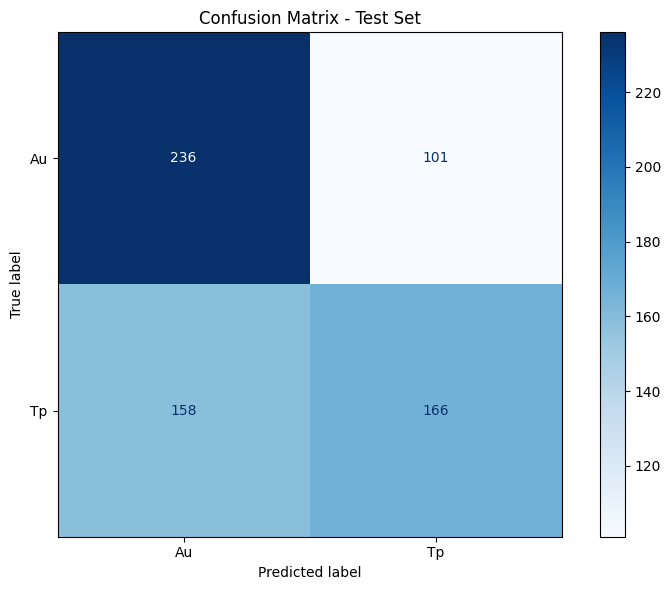


Classification Report:
              precision    recall  f1-score   support

          Au       0.60      0.70      0.65       337
          Tp       0.62      0.51      0.56       324

    accuracy                           0.61       661
   macro avg       0.61      0.61      0.60       661
weighted avg       0.61      0.61      0.60       661


Confusion Matrix Breakdown:
True Negatives (TN):  236
False Positives (FP): 101
False Negatives (FN): 158
True Positives (TP):  166

Sensitivity (Recall): 0.5123
Specificity: 0.7003
Precision: 0.6217


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())


cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Au", "Tp"])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()


print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Au", "Tp"]))


tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print(f"\nSensitivity (Recall): {tp / (tp + fn):.4f}")
print(f"Specificity: {tn / (tn + fp):.4f}")
print(f"Precision: {tp / (tp + fp):.4f}" if (tp + fp) > 0 else "Precision: N/A")

In [20]:
# Build fine-tuning model with ResNet50 backbone
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# Load ResNet50 with ImageNet weights
base_model_ft = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Phase 1: Freeze ALL layers initially
base_model_ft.trainable = False

# Build complete model
inputs_ft = layers.Input(shape=(224, 224, 3))
x_ft = base_model_ft(inputs_ft, training=False)
x_ft = layers.GlobalAveragePooling2D()(x_ft)
x_ft = layers.Dense(256, activation="relu")(x_ft)
x_ft = layers.Dropout(0.5)(x_ft)
outputs_ft = layers.Dense(1, activation="sigmoid")(x_ft)

model_finetune = models.Model(inputs_ft, outputs_ft, name="ResNet50_FineTune")

print(f"Total layers in base model: {len(base_model_ft.layers)}")
print(f"Trainable layers (frozen): {sum([layer.trainable for layer in base_model_ft.layers])}")

Total layers in base model: 175
Trainable layers (frozen): 0


In [ ]:
#Train with frozen base
model_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print("Phase 1: Training with frozen base layers")
history_phase1 = model_finetune.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)



Phase 1: Training with frozen base layers...
Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.5192 - auc: 0.5255 - loss: 0.8551 - val_accuracy: 0.5440 - val_auc: 0.5520 - val_loss: 0.7268
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.5684 - auc: 0.6048 - loss: 0.7274 - val_accuracy: 0.5597 - val_auc: 0.5790 - val_loss: 0.7203
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.6151 - auc: 0.6610 - loss: 0.6707 - val_accuracy: 0.5881 - val_auc: 0.5976 - val_loss: 0.7045
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6465 - auc: 0.6929 - loss: 0.6405 - val_accuracy: 0.5786 - val_auc: 0.5996 - val_loss: 0.7028
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.6664 - auc: 0.7212 - loss: 0.6148 - val_accuracy: 0.6164 - val_auc: 0.6094 - val_loss: 0.7012

Phase 1 complete. New top layers are now warmed up.


In [ ]:

base_model_ft.trainable = True
freeze_until_layer = int(len(base_model_ft.layers) * 0.6)

for i, layer in enumerate(base_model_ft.layers):
    if i < freeze_until_layer:
        layer.trainable = False
    else:
        layer.trainable = True

print(f"Total base layers: {len(base_model_ft.layers)}")
print(f"Frozen layers: {freeze_until_layer}")
print(f"Trainable layers: {sum([layer.trainable for layer in base_model_ft.layers])}")
print(f"\nUnfrozen layers for fine-tuning:")
for i, layer in enumerate(base_model_ft.layers):
    if layer.trainable:
        print(f"  Layer {i}: {layer.name}")

Total base layers: 175
Frozen layers: 105
Trainable layers: 70

Unfrozen layers for fine-tuning:
  Layer 105: conv4_block3_1_relu
  Layer 106: conv4_block3_2_conv
  Layer 107: conv4_block3_2_bn
  Layer 108: conv4_block3_2_relu
  Layer 109: conv4_block3_3_conv
  Layer 110: conv4_block3_3_bn
  Layer 111: conv4_block3_add
  Layer 112: conv4_block3_out
  Layer 113: conv4_block4_1_conv
  Layer 114: conv4_block4_1_bn
  Layer 115: conv4_block4_1_relu
  Layer 116: conv4_block4_2_conv
  Layer 117: conv4_block4_2_bn
  Layer 118: conv4_block4_2_relu
  Layer 119: conv4_block4_3_conv
  Layer 120: conv4_block4_3_bn
  Layer 121: conv4_block4_add
  Layer 122: conv4_block4_out
  Layer 123: conv4_block5_1_conv
  Layer 124: conv4_block5_1_bn
  Layer 125: conv4_block5_1_relu
  Layer 126: conv4_block5_2_conv
  Layer 127: conv4_block5_2_bn
  Layer 128: conv4_block5_2_relu
  Layer 129: conv4_block5_3_conv
  Layer 130: conv4_block5_3_bn
  Layer 131: conv4_block5_add
  Layer 132: conv4_block5_out
  Layer 133: 

In [24]:
model_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]


history_finetune = model_finetune.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)



Phase 2: Fine-tuning upper layers with low learning rate...
Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.6532 - auc: 0.7101 - loss: 0.6247 - val_accuracy: 0.5818 - val_auc: 0.6176 - val_loss: 0.6967 - learning_rate: 1.0000e-05
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - accuracy: 0.7177 - auc: 0.7843 - loss: 0.5652 - val_accuracy: 0.5943 - val_auc: 0.6284 - val_loss: 0.6880 - learning_rate: 1.0000e-05
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.7342 - auc: 0.8036 - loss: 0.5434 - val_accuracy: 0.5975 - val_auc: 0.6294 - val_loss: 0.6881 - learning_rate: 1.0000e-05
Epoch 4/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step - accuracy: 0.7462 - auc: 0.8296 - loss: 0.5138 - val_accuracy: 0.6195 - val_auc: 0.6354 - val_loss: 0.6904 - learning_rate: 1.0000e-05
Epoch 5/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7597 - auc: 0.8488 - loss: 0.4931
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
76/76 ━━━━━━━━━━━━━

In [25]:

ft_test_loss, ft_test_acc, ft_test_auc = model_finetune.evaluate(test_ds)

print(f"Test Loss     : {ft_test_loss:.4f}")
print(f"Test Accuracy : {ft_test_acc:.4f}")
print(f"Test AUC      : {ft_test_auc:.4f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6384 - auc: 0.6764 - loss: 0.7028
Test Loss     : 0.7028
Test Accuracy : 0.6384
Test AUC      : 0.6764


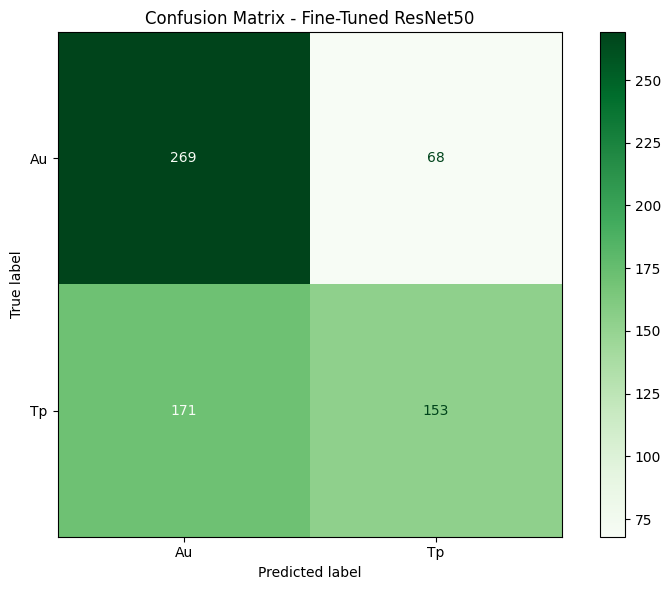


Classification Report (Fine-Tuned):
              precision    recall  f1-score   support

          Au       0.61      0.80      0.69       337
          Tp       0.69      0.47      0.56       324

    accuracy                           0.64       661
   macro avg       0.65      0.64      0.63       661
weighted avg       0.65      0.64      0.63       661

Confusion Matrix Breakdown (Fine-Tuned):
True Negatives (TN):   269  (Authentic correctly identified)
False Positives (FP):   68  (Authentic misclassified as Tampered)
False Negatives (FN):  171  (Tampered misclassified as Authentic)
True Positives (TP):   153  (Tampered correctly identified)
Sensitivity (Recall): 0.4722  (Tampered detection rate)
Specificity:          0.7982  (Authentic detection rate)
Precision:            0.6923  (Tampered prediction accuracy)


In [26]:
# Confusion Matrix for Fine-Tuned Model
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    predictions = model_finetune.predict(images, verbose=0)
    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend((predictions > 0.5).astype(int).flatten())

cm_ft = confusion_matrix(y_true_ft, y_pred_ft)


fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=["Au", "Tp"])
disp.plot(ax=ax, cmap='Greens', values_format='d')
plt.title("Confusion Matrix - Fine-Tuned ResNet50")
plt.tight_layout()
plt.show()


print("\nClassification Report (Fine-Tuned):")
print(classification_report(y_true_ft, y_pred_ft, target_names=["Au", "Tp"]))

# Detailed metrics
tn, fp, fn, tp = cm_ft.ravel()

print(f"Confusion Matrix Breakdown (Fine-Tuned):")

print(f"True Negatives (TN):  {tn:4d}  (Authentic correctly identified)")
print(f"False Positives (FP): {fp:4d}  (Authentic misclassified as Tampered)")
print(f"False Negatives (FN): {fn:4d}  (Tampered misclassified as Authentic)")
print(f"True Positives (TP):  {tp:4d}  (Tampered correctly identified)")

print(f"Sensitivity (Recall): {tp / (tp + fn):.4f}  (Tampered detection rate)")
print(f"Specificity:          {tn / (tn + fp):.4f}  (Authentic detection rate)")
print(f"Precision:            {tp / (tp + fp):.4f}  (Tampered prediction accuracy)" if (tp + fp) > 0 else "Precision: N/A")


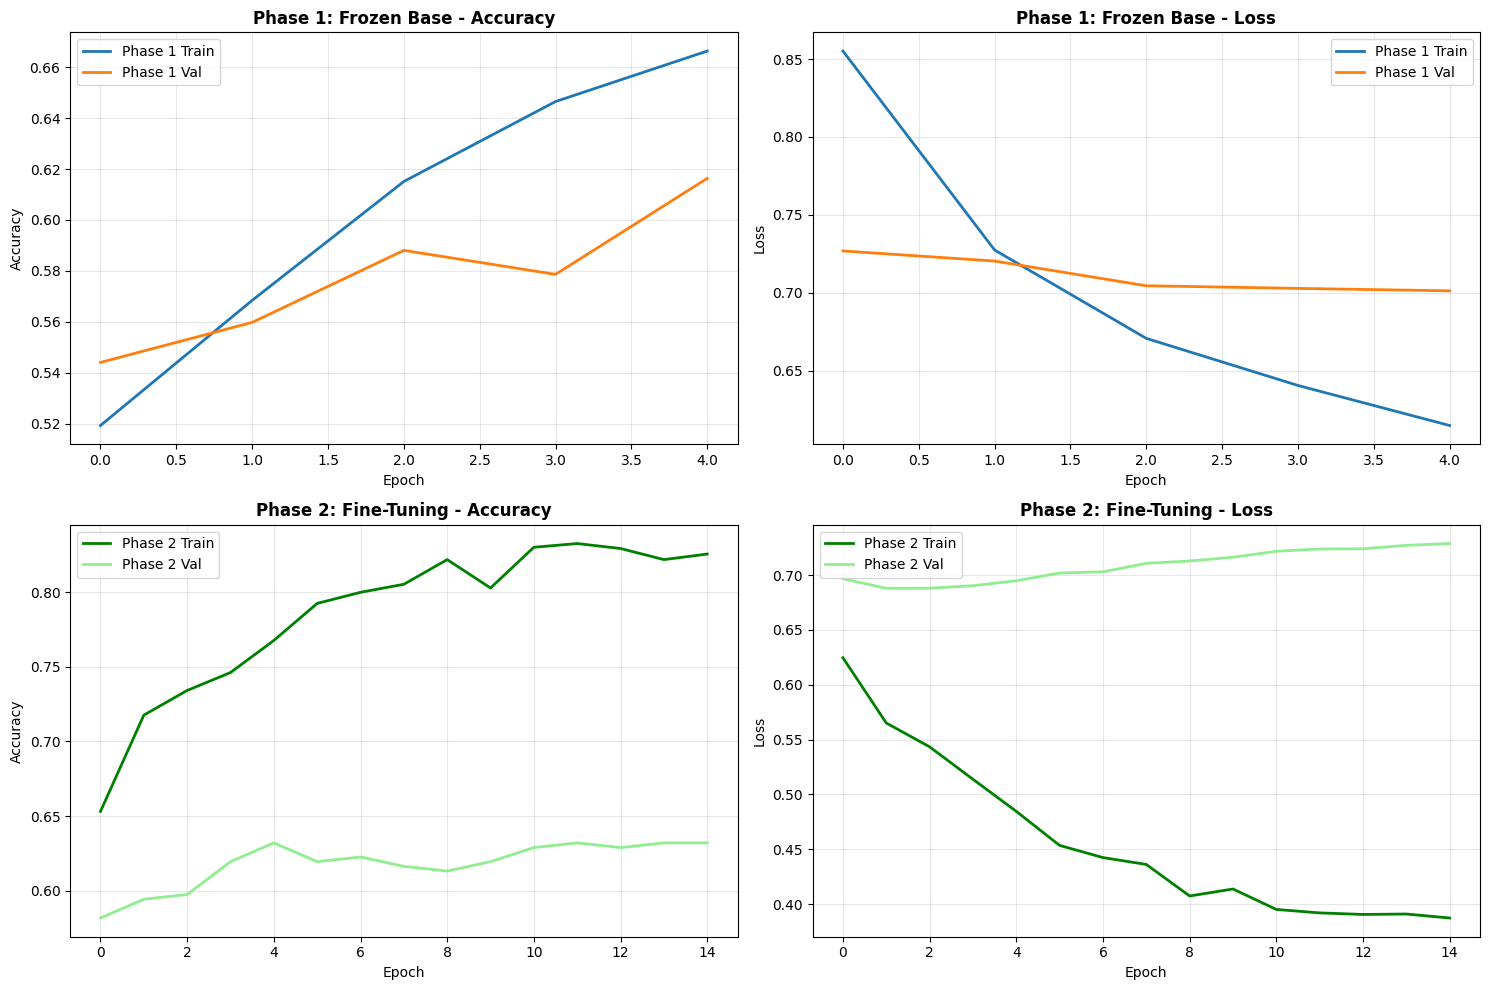

In [27]:
# Plot Training History Comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Phase 1 - Accuracy
axes[0, 0].plot(history_phase1.history['accuracy'], label='Phase 1 Train', linewidth=2)
axes[0, 0].plot(history_phase1.history['val_accuracy'], label='Phase 1 Val', linewidth=2)
axes[0, 0].set_title('Phase 1: Frozen Base - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Phase 1 - Loss
axes[0, 1].plot(history_phase1.history['loss'], label='Phase 1 Train', linewidth=2)
axes[0, 1].plot(history_phase1.history['val_loss'], label='Phase 1 Val', linewidth=2)
axes[0, 1].set_title('Phase 1: Frozen Base - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Phase 2 - Accuracy
axes[1, 0].plot(history_finetune.history['accuracy'], label='Phase 2 Train', linewidth=2, color='green')
axes[1, 0].plot(history_finetune.history['val_accuracy'], label='Phase 2 Val', linewidth=2, color='lightgreen')
axes[1, 0].set_title('Phase 2: Fine-Tuning - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Phase 2 - Loss
axes[1, 1].plot(history_finetune.history['loss'], label='Phase 2 Train', linewidth=2, color='green')
axes[1, 1].plot(history_finetune.history['val_loss'], label='Phase 2 Val', linewidth=2, color='lightgreen')
axes[1, 1].set_title('Phase 2: Fine-Tuning - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Overfitting Analysis & Solutions

**Problem:** Low training loss, high validation loss = model memorizing training data instead of generalizing.

**Root Causes:**
- Insufficient data augmentation
- Not enough regularization
- Model capacity too high for dataset size
- Possible class imbalance

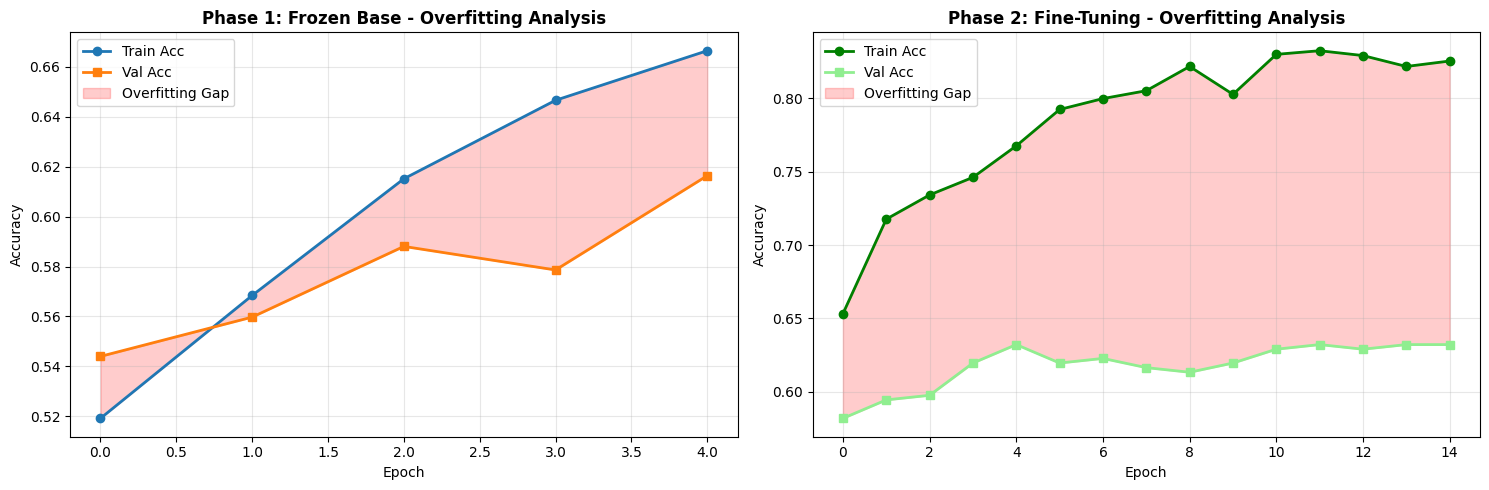

OVERFITTING ANALYSIS

Phase 1 (Frozen Base):
  Max Train Acc: 0.6664
  Max Val Acc:   0.6164
  Overfitting Gap: 0.0679 (should be < 0.10)

Phase 2 (Fine-Tuning):
  Max Train Acc: 0.8326
  Max Val Acc:   0.6321
  Overfitting Gap: 0.2086 (should be < 0.10)

⚠️  HIGH OVERFITTING DETECTED! Gap > 0.10


In [28]:
# Detect overfitting gap
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Phase 1 overfitting
train_acc_p1 = history_phase1.history['accuracy']
val_acc_p1 = history_phase1.history['val_accuracy']
gap_p1 = [t - v for t, v in zip(train_acc_p1, val_acc_p1)]

ax1.plot(train_acc_p1, label='Train Acc', linewidth=2, marker='o')
ax1.plot(val_acc_p1, label='Val Acc', linewidth=2, marker='s')
ax1.fill_between(range(len(gap_p1)), train_acc_p1, val_acc_p1, alpha=0.2, color='red', label='Overfitting Gap')
ax1.set_title('Phase 1: Frozen Base - Overfitting Analysis', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Phase 2 overfitting
train_acc_p2 = history_finetune.history['accuracy']
val_acc_p2 = history_finetune.history['val_accuracy']
gap_p2 = [t - v for t, v in zip(train_acc_p2, val_acc_p2)]

ax2.plot(train_acc_p2, label='Train Acc', linewidth=2, marker='o', color='green')
ax2.plot(val_acc_p2, label='Val Acc', linewidth=2, marker='s', color='lightgreen')
ax2.fill_between(range(len(gap_p2)), train_acc_p2, val_acc_p2, alpha=0.2, color='red', label='Overfitting Gap')
ax2.set_title('Phase 2: Fine-Tuning - Overfitting Analysis', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print overfitting metrics
print(f"{'='*70}")
print(f"OVERFITTING ANALYSIS")
print(f"{'='*70}")
print(f"\nPhase 1 (Frozen Base):")
print(f"  Max Train Acc: {max(train_acc_p1):.4f}")
print(f"  Max Val Acc:   {max(val_acc_p1):.4f}")
print(f"  Overfitting Gap: {max(gap_p1):.4f} (should be < 0.10)")

print(f"\nPhase 2 (Fine-Tuning):")
print(f"  Max Train Acc: {max(train_acc_p2):.4f}")
print(f"  Max Val Acc:   {max(val_acc_p2):.4f}")
print(f"  Overfitting Gap: {max(gap_p2):.4f} (should be < 0.10)")

if max(gap_p1) > 0.10 or max(gap_p2) > 0.10:
    print(f"\n⚠️  HIGH OVERFITTING DETECTED! Gap > 0.10")
else:
    print(f"\n✓ Overfitting within acceptable range")

print(f"{'='*70}")

In [29]:
# Solution: Improved Model with Better Regularization & Augmentation
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50

print("Building improved model with enhanced regularization...")

# Load ResNet50
base_model_improved = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers initially
base_model_improved.trainable = False

# Build model with STRONGER regularization
inputs_improved = layers.Input(shape=(224, 224, 3))
x = base_model_improved(inputs_improved, training=False)
x = layers.GlobalAveragePooling2D()(x)

# MORE AGGRESSIVE REGULARIZATION
x = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.L2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.6)(x)  # Increased from 0.5 to 0.6

x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.L2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.6)(x)  # Increased from 0.5 to 0.6

x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.L2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs_improved = layers.Dense(1, activation="sigmoid")(x)

model_improved = models.Model(inputs_improved, outputs_improved, name="ResNet50_Improved")

print(f"Model built with enhanced regularization:")
print(f"  - Stronger Dropout (0.6)")
print(f"  - L2 Regularization (1e-4)")
print(f"  - BatchNormalization layers")
print(f"  - More dense layers for capacity reduction")

Building improved model with enhanced regularization...
Model built with enhanced regularization:
  - Stronger Dropout (0.6)
  - L2 Regularization (1e-4)
  - BatchNormalization layers
  - More dense layers for capacity reduction


In [30]:
# Create improved datasets with STRONGER augmentation
print("Creating improved datasets with aggressive augmentation...")

# Aggressive augmentation for training
train_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.2),  # Increased from 0.05
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

# Reload datasets with augmentation
train_ds_improved = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\train",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"],
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

val_ds_improved = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\val",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"],
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_ds_improved = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\test",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"],
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

def preprocess_improved(image, label):
    # Rescale
    image = image / 255.0
    # Apply augmentation only to training
    image = train_augmentation(image)
    return image, label

def preprocess_val_test(image, label):
    # Just rescale for val/test
    image = image / 255.0
    return image, label

train_ds_improved = train_ds_improved.map(preprocess_improved, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_improved = val_ds_improved.map(preprocess_val_test, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_improved = test_ds_improved.map(preprocess_val_test, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("✓ Datasets ready with aggressive augmentation")

Creating improved datasets with aggressive augmentation...
Found 2419 files belonging to 2 classes.
Found 318 files belonging to 2 classes.
Found 661 files belonging to 2 classes.
✓ Datasets ready with aggressive augmentation


In [ ]:
# Train improved model: Phase 1 (frozen base)
print("\n" + "="*70)
print("PHASE 1: Training with frozen base + strong regularization")
print("="*70)

model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks_improved = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        mode='min',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_improved_p1 = model_improved.fit(
    train_ds_improved,
    validation_data=val_ds_improved,
    epochs=10,
    callbacks=callbacks_improved,
    verbose=1
)

print("\n✓ Phase 1 complete")


PHASE 1: Training with frozen base + strong regularization
Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.5143 - auc: 0.5179 - loss: 1.0704 - val_accuracy: 0.4654 - val_auc: 0.5212 - val_loss: 0.8274 - learning_rate: 1.0000e-04
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.4919 - auc: 0.4906 - loss: 1.1077 - val_accuracy: 0.4654 - val_auc: 0.5019 - val_loss: 0.8731 - learning_rate: 1.0000e-04
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4990 - auc: 0.4953 - loss: 1.0781
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
76/76 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.5010 - auc: 0.5017 - loss: 1.0578 - val_accuracy: 0.4654 - val_auc: 0.4875 - val_loss: 0.8633 - learning_rate: 1.0000e-04
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.4804 - auc: 0.4919 - loss: 1.0266 - val_accuracy: 0.4654 - val_auc: 0.4756 - val_loss: 0.8556 - learning_rate: 5.0000e-05
Epoch 4: early stopping
Restor

In [32]:
# Phase 2: Fine-tune with upper layers unfrozen
print("\n" + "="*70)
print("PHASE 2: Fine-tuning upper layers")
print("="*70)

base_model_improved.trainable = True
freeze_until = int(len(base_model_improved.layers) * 0.6)

for i, layer in enumerate(base_model_improved.layers):
    layer.trainable = (i >= freeze_until)

# Recompile with ultra-low learning rate
model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history_improved_p2 = model_improved.fit(
    train_ds_improved,
    validation_data=val_ds_improved,
    epochs=15,
    callbacks=callbacks_improved,
    verbose=1
)

print("\n✓ Phase 2 complete")


PHASE 2: Fine-tuning upper layers
Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.5019 - auc: 0.5068 - loss: 1.0974 - val_accuracy: 0.4654 - val_auc: 0.4764 - val_loss: 0.8819 - learning_rate: 1.0000e-05
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5015 - auc: 0.4991 - loss: 1.1192
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
76/76 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step - accuracy: 0.5122 - auc: 0.5118 - loss: 1.0901 - val_accuracy: 0.4654 - val_auc: 0.4804 - val_loss: 0.8996 - learning_rate: 1.0000e-05
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 283s 4s/step - accuracy: 0.5056 - auc: 0.5102 - loss: 1.0855 - val_accuracy: 0.4686 - val_auc: 0.5253 - val_loss: 0.9195 - learning_rate: 5.0000e-06
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

✓ Phase 2 complete


In [33]:
# Evaluate improved model
print("\n" + "="*70)
print("IMPROVED MODEL - TEST EVALUATION")
print("="*70)

improved_test_loss, improved_test_acc, improved_test_auc = model_improved.evaluate(test_ds_improved, verbose=0)

print(f"\nTest Loss:     {improved_test_loss:.4f}")
print(f"Test Accuracy: {improved_test_acc:.4f}")
print(f"Test AUC:      {improved_test_auc:.4f}")

# Compare with original
print(f"\n{'='*70}")
print(f"MODEL COMPARISON")
print(f"{'='*70}")
print(f"{'Model':<25} {'Test Acc':<15} {'Test AUC':<15}")
print(f"{'-'*70}")
print(f"{'Original Fine-Tuned':<25} {ft_test_acc:<15.4f} {ft_test_auc:<15.4f}")
print(f"{'Improved (Regularized)':<25} {improved_test_acc:<15.4f} {improved_test_auc:<15.4f}")

improvement = (improved_test_acc - ft_test_acc) * 100
print(f"\nImprovement: {improvement:+.2f}%")
print(f"{'='*70}")


IMPROVED MODEL - TEST EVALUATION

Test Loss:     0.8622
Test Accuracy: 0.4902
Test AUC:      0.5199

MODEL COMPARISON
Model                     Test Acc        Test AUC       
----------------------------------------------------------------------
Original Fine-Tuned       0.6384          0.6764         
Improved (Regularized)    0.4902          0.5199         

Improvement: -14.83%
